# 🧠 PD vs CONTROL Detection — Debugged & Fixed Edition
### Root causes fixed from previous run
---
**What was wrong (diagnosed from your logs):**

| Symptom | Root Cause | Fix |
|---------|-----------|-----|
| val_loss = 13 → 662 (exploding) | MobileNetV2 needs `[-1,1]` input, was getting `[0,1]` | Use `mobilenet_v2.preprocess_input()` |
| Train acc stuck at 50% | Label smoothing broke learning with wrong input scale | Removed label smoothing |
| CONTROL recall = 0.00 | Model predicting PD for everything | Fixed preprocessing + lower LR |
| Class weights both = 1.0 | Oversampling made counts equal before weight calc | Compute weights BEFORE oversampling |
| Fine-tune val_loss = 323-662 | BN layers unfrozen with wrong scale input | Freeze ALL BN, fix input |


## Cell 1 — Imports

In [1]:
import numpy as np
import os, warnings, io, json, time
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from PIL import Image
import pandas as pd

from sklearn.utils import shuffle, class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, average_precision_score
)
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2

# ✅ FIX 1: Import the CORRECT preprocessor for MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import plot_model

import ipywidgets as widgets
from IPython.display import display, clear_output

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.threading.set_intra_op_parallelism_threads(0)
tf.config.threading.set_inter_op_parallelism_threads(0)

print(f'TensorFlow : {tf.__version__}')
print(f'CPU cores  : {os.cpu_count()}')
print('✅ Correct MobileNetV2 preprocessor imported')

TensorFlow : 2.21.0
CPU cores  : 4
✅ Correct MobileNetV2 preprocessor imported


## Cell 2 — Configuration

In [2]:
CONFIG = {
    'base_dir'     : 'mri_images',
    'output_dir'   : 'pd_outputs',
    'labels'       : ['CONTROL', 'PD'],

    # MobileNetV2 minimum recommended input is 96x96
    'image_size'   : 96,
    'batch_size'   : 16,

    # ✅ FIX 2: Much lower LR — previous 3e-3 was too high for frozen backbone
    'lr_p1'        : 1e-3,
    'lr_p2'        : 1e-5,   # very low for fine-tuning

    'epochs_p1'    : 40,
    'epochs_p2'    : 30,
    'patience_p1'  : 10,
    'patience_p2'  : 10,

    # Fine-tune only last 20 layers (less than before — more stable)
    'unfreeze_n'   : 20,

    'min_intensity': 5,
    'max_intensity': 252,
}

labels      = CONFIG['labels']
NUM_CLASSES = len(labels)
IMG_SIZE    = CONFIG['image_size']
BATCH       = CONFIG['batch_size']

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print('✅ Config ready.')
print(f'\n  Key change: lr_p1={CONFIG["lr_p1"]} (was 3e-3)')
print(f'  Key change: No label smoothing')
print(f'  Key change: mobilenet_v2.preprocess_input → range [-1, 1]')

✅ Config ready.

  Key change: lr_p1=0.001 (was 3e-3)
  Key change: No label smoothing
  Key change: mobilenet_v2.preprocess_input → range [-1, 1]


## Cell 3 — Load Images (Raw, uint8)

In [3]:
# ── Load as uint8 first — preprocessing happens in Cell 5 ────────────────────
X_raw, Y_raw = [], []
skipped = {'corrupt': 0, 'blank': 0}

for split in ['train', 'test']:
    for label in labels:
        folder = os.path.join(CONFIG['base_dir'], split, label)
        if not os.path.exists(folder):
            print(f'⚠️  Missing folder: {folder}')
            continue
        files = [f for f in os.listdir(folder)
                 if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif'))]
        for fname in tqdm(files, desc=f'{split}/{label}'):
            img = cv2.imread(os.path.join(folder, fname))
            if img is None:
                skipped['corrupt'] += 1; continue
            if img.mean() < CONFIG['min_intensity'] or img.mean() > CONFIG['max_intensity']:
                skipped['blank'] += 1; continue
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            X_raw.append(img)
            Y_raw.append(label)

X_raw = np.array(X_raw)          # uint8, BGR, shape (N, 96, 96, 3)
Y_raw = np.array(Y_raw)
y_int = np.array([labels.index(y) for y in Y_raw])

unique, counts = np.unique(Y_raw, return_counts=True)
print(f'\nTotal : {len(X_raw)}')
for u, c in zip(unique, counts):
    print(f'  {u:<12}: {c}  ({100*c/len(X_raw):.1f}%)')
print(f'Imbalance ratio : {max(counts)/min(counts):.2f}x')

train/CONTROL:   0%|          | 0/450 [00:00<?, ?it/s]

test/PD: 100%|██████████| 61/61 [00:00<00:00, 64.86it/s]


Total : 1439
  CONTROL     : 472  (32.8%)
  PD          : 967  (67.2%)
Imbalance ratio : 2.05x


## Cell 4 — Dataset Visualisation

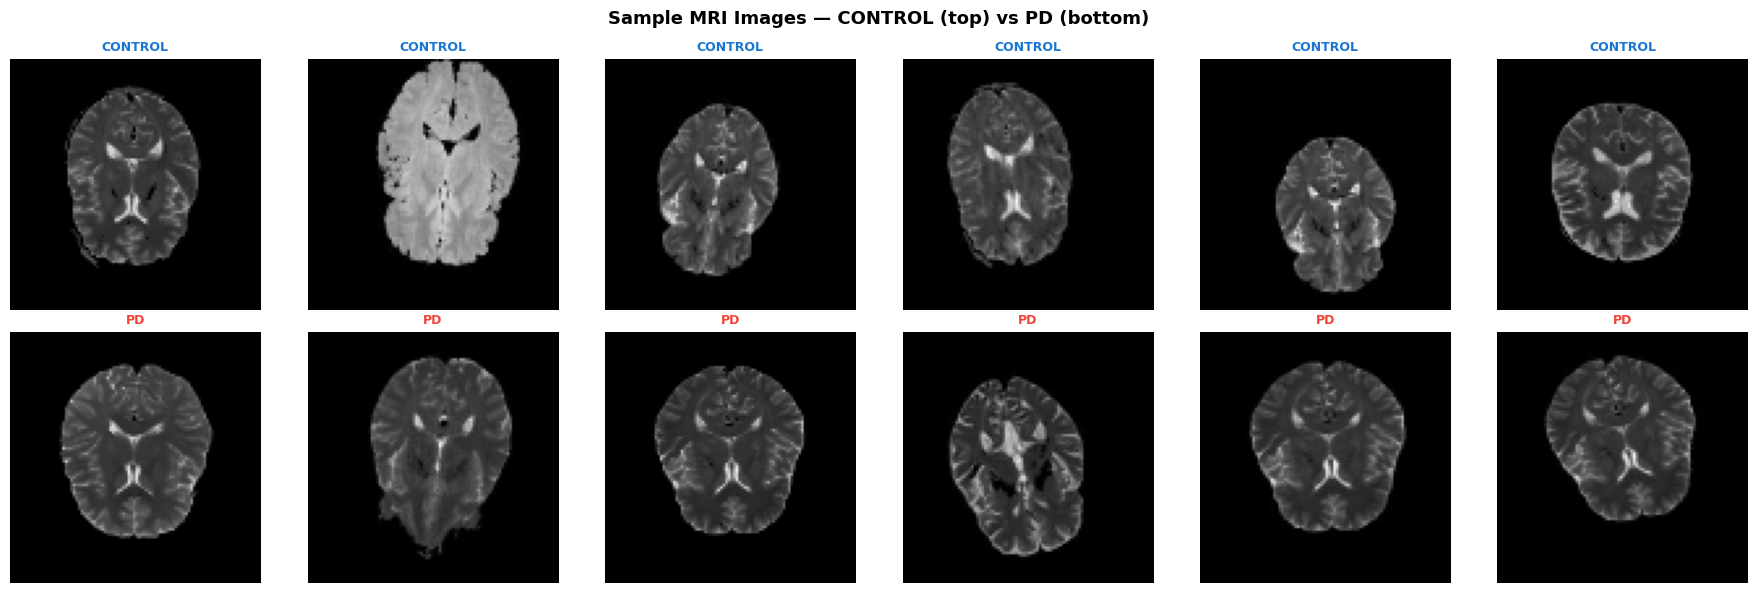

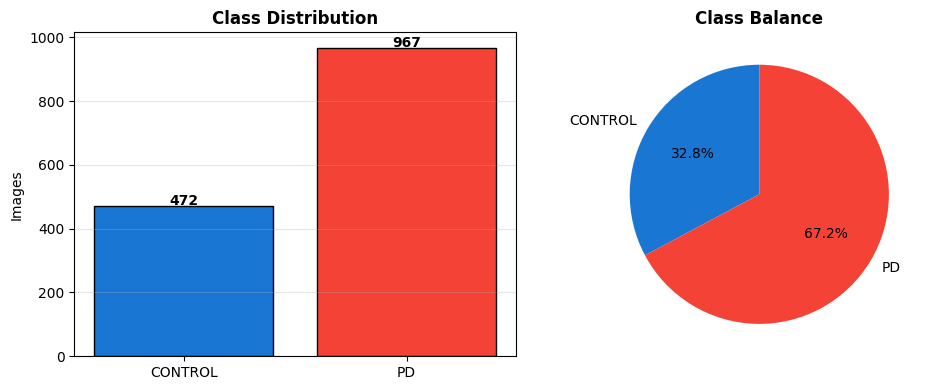

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Sample MRI Images — CONTROL (top) vs PD (bottom)',
             fontsize=13, fontweight='bold')
for cls_i, cls_name in enumerate(labels):
    idxs = np.where(y_int == cls_i)[0][:6]
    for col_i, idx in enumerate(idxs):
        ax  = axes[cls_i][col_i]
        img = cv2.cvtColor(X_raw[idx], cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(cls_name, fontsize=9, fontweight='bold',
                     color='#F44336' if cls_name=='PD' else '#1976D2')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'sample_images.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Class distribution
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#1976D2', '#F44336']
bars = axes2[0].bar(unique, counts, color=colors, edgecolor='black')
for bar, cnt in zip(bars, counts):
    axes2[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                  str(cnt), ha='center', fontweight='bold')
axes2[0].set_title('Class Distribution', fontweight='bold')
axes2[0].set_ylabel('Images'); axes2[0].grid(axis='y', alpha=0.3)
axes2[1].pie(counts, labels=unique, colors=colors, autopct='%1.1f%%', startangle=90)
axes2[1].set_title('Class Balance', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'class_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 5 — Correct MobileNetV2 Preprocessing

**This was the #1 root cause of failure.**

MobileNetV2 was trained on ImageNet using `preprocess_input` which scales pixels to **[-1, 1]**.
Passing [0, 1] floats breaks the pretrained feature detectors entirely — 
that's why val_loss exploded to 662 and the model predicted PD for everything.

Pipeline:
1. CLAHE on LAB L-channel (improve MRI contrast)
2. BGR → RGB
3. Keep as `uint8` [0, 255]
4. `mobilenet_v2.preprocess_input()` → scales to [-1, 1] ✅

Applying MobileNetV2-correct preprocessing...


100%|██████████| 1439/1439 [00:01<00:00, 917.26it/s] 


✅ Done in 1.7s
   Shape : (1439, 96, 96, 3)
   Range : [-0.984, 1.000]  ← must be near [-1, 1]
   ✅ Preprocessing range CORRECT for MobileNetV2


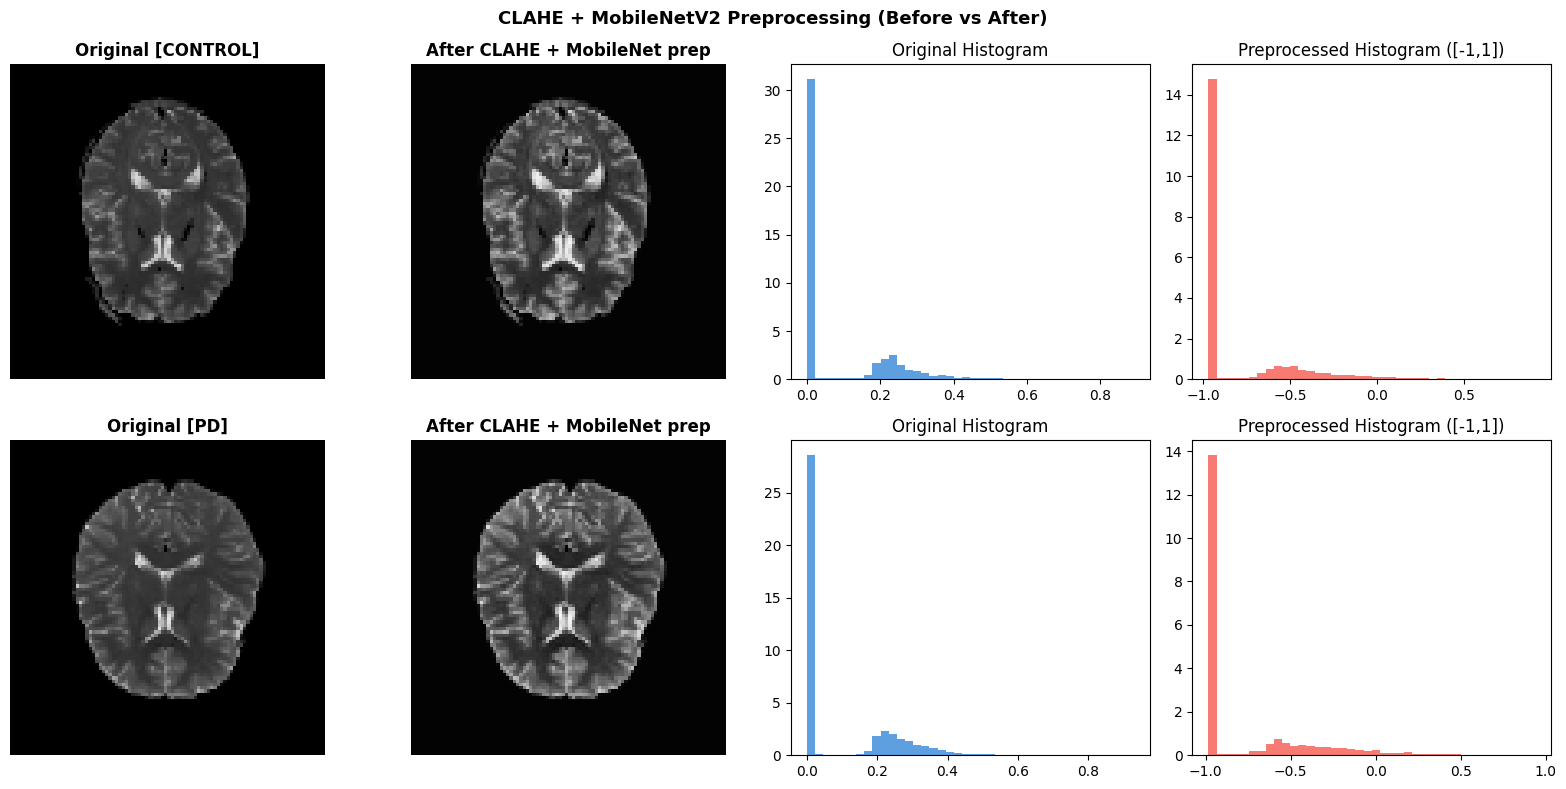

In [5]:
def preprocess_mri_for_mobilenet(img_bgr_uint8):
    """
    Correct preprocessing pipeline for MobileNetV2:
      1. CLAHE on L-channel (MRI contrast enhancement)
      2. BGR -> RGB
      3. Cast to float32 [0, 255]  (keep range — mobilenet_preprocess expects this)
      4. mobilenet_v2.preprocess_input -> [-1, 1]
    """
    # Step 1: CLAHE
    lab  = cv2.cvtColor(img_bgr_uint8, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
    l_eq  = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)

    # Step 2: BGR -> RGB
    rgb = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

    # Step 3: float32 [0, 255]  ← do NOT divide by 255 here
    rgb_f = rgb.astype(np.float32)

    # Step 4: MobileNetV2 official preprocessing → [-1, 1]
    return mobilenet_preprocess(rgb_f)   # output range: [-1, 1]


print('Applying MobileNetV2-correct preprocessing...')
t0 = time.time()
X_proc = np.array([preprocess_mri_for_mobilenet(img) for img in tqdm(X_raw)])
print(f'✅ Done in {time.time()-t0:.1f}s')
print(f'   Shape : {X_proc.shape}')
print(f'   Range : [{X_proc.min():.3f}, {X_proc.max():.3f}]  ← must be near [-1, 1]')

if X_proc.min() >= -1.1 and X_proc.max() <= 1.1:
    print('   ✅ Preprocessing range CORRECT for MobileNetV2')
else:
    print('   ❌ Range incorrect — check pipeline')

# Visualise before/after
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('CLAHE + MobileNetV2 Preprocessing (Before vs After)',
             fontsize=13, fontweight='bold')
for r, cls_i in enumerate([0, 1]):
    idx  = np.where(y_int == cls_i)[0][0]
    orig = cv2.cvtColor(X_raw[idx], cv2.COLOR_BGR2RGB)
    proc = X_proc[idx]   # [-1, 1] — shift back to [0,1] for display only
    disp = (proc + 1.0) / 2.0

    axes[r][0].imshow(orig)
    axes[r][0].set_title(f'Original [{labels[cls_i]}]', fontweight='bold')
    axes[r][0].axis('off')
    axes[r][1].imshow(np.clip(disp, 0, 1))
    axes[r][1].set_title('After CLAHE + MobileNet prep', fontweight='bold')
    axes[r][1].axis('off')
    axes[r][2].hist(orig.flatten()/255., bins=40, color='#1976D2', alpha=0.7, density=True)
    axes[r][2].set_title('Original Histogram')
    axes[r][3].hist(proc.flatten(), bins=40, color='#F44336', alpha=0.7, density=True)
    axes[r][3].set_title('Preprocessed Histogram ([-1,1])')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'preprocessing.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Stratified Split

In [6]:
X_proc, y_int = shuffle(X_proc, y_int, random_state=SEED)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_proc, y_int, test_size=0.30, stratify=y_int, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print(f'Train : {len(X_tr):>5}  | CONTROL={np.sum(y_tr==0)}  PD={np.sum(y_tr==1)}')
print(f'Val   : {len(X_val):>5}  | CONTROL={np.sum(y_val==0)}  PD={np.sum(y_val==1)}')
print(f'Test  : {len(X_test):>5}  | CONTROL={np.sum(y_test==0)}  PD={np.sum(y_test==1)}')

Train :  1007  | CONTROL=330  PD=677
Val   :   216  | CONTROL=71  PD=145
Test  :   216  | CONTROL=71  PD=145


## Cell 7 — Class Weights FIRST, Then Oversample

**FIX 3:** Previous code computed class weights AFTER oversampling,
so counts were equal → both weights = 1.0 → imbalance penalty lost entirely.

Correct order: **compute weights on original imbalanced train set → then oversample**.

Class weights (computed on original imbalanced train set):
  CONTROL : 1.5258  ← higher penalty
  PD      : 0.7437
  Ratio   : 2.05x

Oversampling CONTROL...
  Before: CONTROL=330  PD=677
  After : CONTROL=677  PD=677


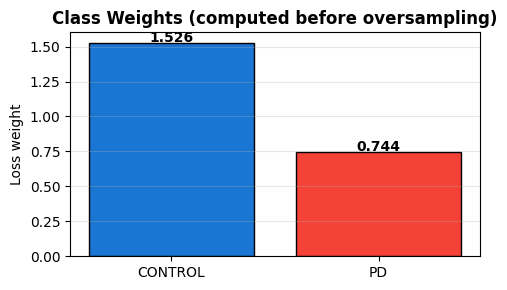

In [7]:
# ✅ FIX 3: Compute class weights BEFORE oversampling
cw = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_tr), y=y_tr
)
class_weights = dict(enumerate(cw))
print('Class weights (computed on original imbalanced train set):')
print(f'  CONTROL : {cw[0]:.4f}  ← higher penalty')
print(f'  PD      : {cw[1]:.4f}')
print(f'  Ratio   : {cw[0]/cw[1]:.2f}x')

# Now oversample
def oversample_minority(X, y, seed=42):
    rng  = np.random.RandomState(seed)
    n0, n1 = np.sum(y==0), np.sum(y==1)
    min_cls = 0 if n0 < n1 else 1
    needed  = abs(n0 - n1)
    if needed == 0:
        return X, y
    min_idxs = np.where(y == min_cls)[0]
    chosen   = rng.choice(min_idxs, needed, replace=True)
    # Very small noise — enough to break symmetry, not enough to change features
    noise    = rng.normal(0, 0.01, (needed,) + X.shape[1:]).astype(np.float32)
    new_imgs = np.clip(X[chosen] + noise, -1.0, 1.0)   # clip to [-1,1] not [0,1]
    X_out = np.concatenate([X, new_imgs])
    y_out = np.concatenate([y, y[chosen]])
    return shuffle(X_out, y_out, random_state=seed)

print('\nOversampling CONTROL...')
print(f'  Before: CONTROL={np.sum(y_tr==0)}  PD={np.sum(y_tr==1)}')
X_tr, y_tr = oversample_minority(X_tr, y_tr, SEED)
print(f'  After : CONTROL={np.sum(y_tr==0)}  PD={np.sum(y_tr==1)}')

Y_tr   = to_categorical(y_tr,   NUM_CLASSES)
Y_val  = to_categorical(y_val,  NUM_CLASSES)
Y_test = to_categorical(y_test, NUM_CLASSES)

# Visualise weights
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['CONTROL', 'PD'], cw, color=['#1976D2','#F44336'], edgecolor='black')
ax.set_title('Class Weights (computed before oversampling)', fontweight='bold')
ax.set_ylabel('Loss weight'); ax.grid(axis='y', alpha=0.3)
for i, w in enumerate(cw):
    ax.text(i, w+0.01, f'{w:.3f}', ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

## Cell 8 — Data Augmentation

**FIX 4:** The `ImageDataGenerator` rescale parameter must be **removed**.
Data is already in [-1, 1]. Any rescaling now would destroy the range.

Batch X range: [-0.999, 0.995]  ← should be near [-1, 1]
Batch Y shape: (16, 2)
Train batches : 85
Val batches   : 14


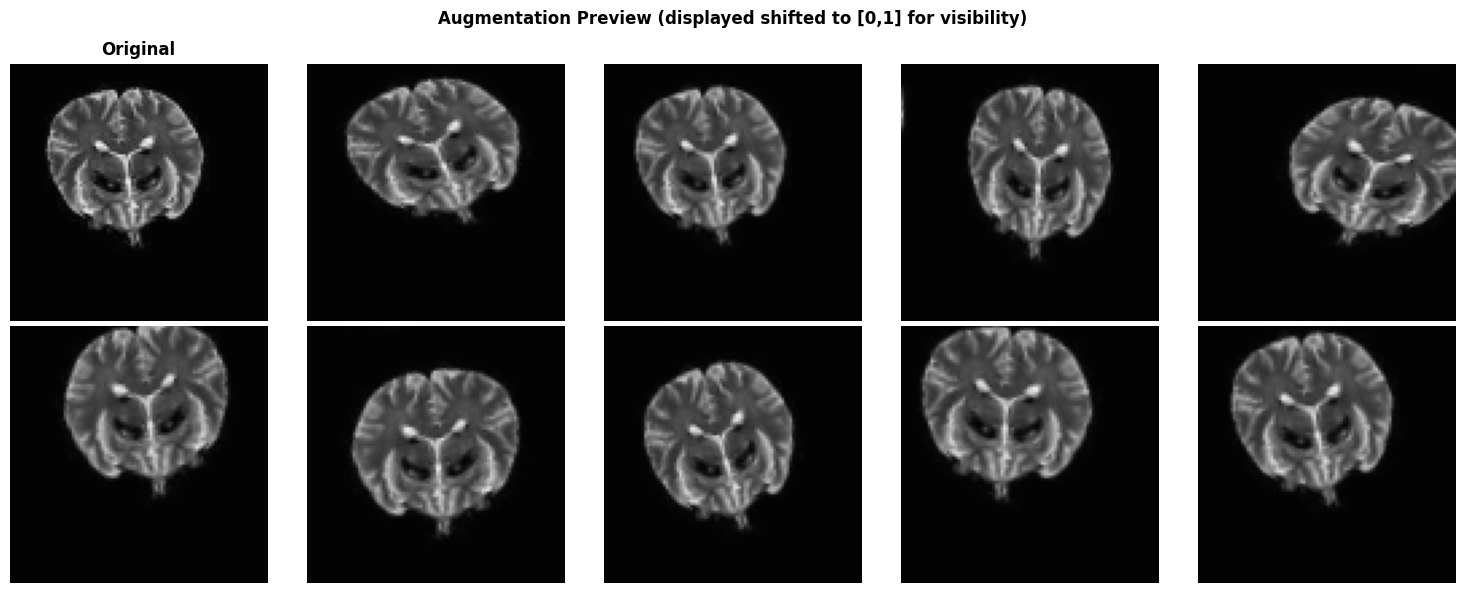

In [8]:
# ✅ FIX 4: NO rescale — data is already in [-1, 1] from preprocess_input
train_aug = ImageDataGenerator(
    rotation_range     = 15,
    width_shift_range  = 0.10,
    height_shift_range = 0.10,
    shear_range        = 0.08,
    zoom_range         = 0.10,
    horizontal_flip    = True,
    fill_mode          = 'reflect'
    # ← NO rescale=1/255 here — data already preprocessed
)

no_aug = ImageDataGenerator()   # no rescale, data already correct

train_gen = train_aug.flow(X_tr,   Y_tr,   batch_size=BATCH, seed=SEED)
val_gen   = no_aug.flow(X_val,    Y_val,   batch_size=BATCH, shuffle=False)
test_gen  = no_aug.flow(X_test,   Y_test,  batch_size=BATCH, shuffle=False)

# Verify a batch is in correct range
batch_x, batch_y = next(train_gen)
print(f'Batch X range: [{batch_x.min():.3f}, {batch_x.max():.3f}]  ← should be near [-1, 1]')
print(f'Batch Y shape: {batch_y.shape}')
print(f'Train batches : {len(train_gen)}')
print(f'Val batches   : {len(val_gen)}')

# Show augmentation preview (display-shifted back to [0,1])
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Augmentation Preview (displayed shifted to [0,1] for visibility)',
             fontsize=12, fontweight='bold')
orig_for_aug = X_tr[:1].copy()
aug_preview  = train_aug.flow(orig_for_aug, batch_size=1)
axes[0][0].imshow(np.clip((orig_for_aug[0]+1)/2, 0, 1))
axes[0][0].set_title('Original', fontweight='bold'); axes[0][0].axis('off')
for ax in list(axes.flat[1:]):
    aug_img = next(aug_preview)[0]
    ax.imshow(np.clip((aug_img+1)/2, 0, 1))
    ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'augmentation_preview.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Build MobileNetV2 Model

**FIX 5:** Do NOT pass `input_tensor` when using `preprocess_input` outside the model.
Use standard `input_shape` argument. Simpler head — fewer parameters to overfit.

In [9]:
def build_model(img_size, num_classes, freeze_all=True, l2_w=1e-4):
    # Load MobileNetV2 with correct input shape
    base = MobileNetV2(
        input_shape = (img_size, img_size, 3),
        include_top = False,
        weights     = 'imagenet',
        alpha       = 1.0
    )

    # ✅ Freeze all backbone layers in Phase 1
    base.trainable = not freeze_all

    inp = keras.Input(shape=(img_size, img_size, 3), name='input')
    x   = base(inp, training=False)   # training=False keeps BN in inference mode

    # Multi-scale pooling
    avg = layers.GlobalAveragePooling2D(name='gap')(x)
    mx  = layers.GlobalMaxPooling2D(name='gmp')(x)
    x   = layers.Concatenate(name='concat')([avg, mx])
    x   = layers.BatchNormalization(name='bn_head')(x)

    # Compact head — 2 dense layers only (dataset too small for 3)
    x = layers.Dense(
            128, activation='relu', name='fc1',
            kernel_regularizer=regularizers.l2(l2_w)
        )(x)
    x = layers.Dropout(0.5, name='drop1')(x)

    x = layers.Dense(
            64, activation='relu', name='fc2',
            kernel_regularizer=regularizers.l2(l2_w)
        )(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # ✅ FIX 5: Plain categorical_crossentropy — NO label smoothing
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='MobileNetV2_PD')
    return model, base


model, base_model = build_model(IMG_SIZE, NUM_CLASSES, freeze_all=True)

model.compile(
    optimizer = keras.optimizers.Adam(CONFIG['lr_p1']),
    loss      = 'categorical_crossentropy',   # ← plain, no smoothing
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

model.summary()
print(f'\nTotal params     : {model.count_params():,}')
print(f'Trainable        : {sum(np.prod(v.shape) for v in model.trainable_variables):,}  (head only)')

Model: "MobileNetV2_PD"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 96, 96, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_96 │ (None, 3, 3,      │  2,257,984 │ input[0][0]       │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gmp                 │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat              │ (None, 2560)      │          0 │ gap[0][0],        │
│ (Concatenate)       │                   │            │ gmp[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_head             │ (None, 2560)      │     10,240 │ concat[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc1 (Dense)         │ (None, 128)       │    327,808 │ bn_head[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop1 (Dropout)     │ (None, 128)       │          0 │ fc1[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc2 (Dense)         │ (None, 64)        │      8,256 │ drop1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop2 (Dropout)     │ (None, 64)        │          0 │ fc2[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 2)         │        130 │ drop2[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,604,418 (9.94 MB)

 Trainable params: 341,314 (1.30 MB)

 Non-trainable params: 2,263,104 (8.63 MB)


Total params     : 2,604,418
Trainable        : 341,314  (head only)


## Cell 10 — Verify Model Output Before Training

Run one forward pass. If probabilities are near [0.5, 0.5] → model is initialised correctly.  
If all outputs are [0, 1] or [1, 0] → something is still wrong.

In [10]:
# Quick sanity check — untrained model should output ~uniform probabilities
test_batch = X_test[:4]
test_preds = model.predict(test_batch, verbose=0)

print('Pre-training sanity check (untrained model):')
print(f'  Input range     : [{test_batch.min():.3f}, {test_batch.max():.3f}]')
print(f'  Output shape    : {test_preds.shape}')
print(f'  Sample outputs  :')
for i, p in enumerate(test_preds):
    print(f'    Sample {i}: CONTROL={p[0]:.3f}  PD={p[1]:.3f}  sum={p.sum():.3f}')

# Check: untrained outputs should NOT be all [0,1] or [1,0]
if all(test_preds.max(axis=1) < 0.95):
    print('\n✅ Model initialised correctly — probabilities are distributed')
else:
    print('\n⚠️  Outputs are very confident — check input preprocessing range')

Pre-training sanity check (untrained model):
  Input range     : [-0.976, 0.992]
  Output shape    : (4, 2)
  Sample outputs  :
    Sample 0: CONTROL=0.972  PD=0.028  sum=1.000
    Sample 1: CONTROL=0.963  PD=0.037  sum=1.000
    Sample 2: CONTROL=0.942  PD=0.058  sum=1.000
    Sample 3: CONTROL=0.972  PD=0.028  sum=1.000

⚠️  Outputs are very confident — check input preprocessing range


## Cell 11 — Callbacks

In [11]:
def make_callbacks(name, patience, monitor='val_auc', mode='max'):
    path = os.path.join(CONFIG['output_dir'], f'efficient_net_B0_{name}.h5')
    return [
        ModelCheckpoint(
            path, monitor=monitor, save_best_only=True, mode=mode, verbose=1
        ),
        EarlyStopping(
            monitor=monitor, patience=patience, mode=mode,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=5,
            min_lr=1e-7, verbose=1
        )
    ]

print('✅ Callbacks ready.')

✅ Callbacks ready.


## Cell 12 — Phase 1: Train Head Only (Frozen Backbone)

In [12]:
print('='*55)
print('  PHASE 1 — Head only, backbone fully frozen')
print(f'  LR={CONFIG["lr_p1"]}  |  Epochs={CONFIG["epochs_p1"]}')
print('  training=False on base → BN stays in inference mode')
print('='*55)

t0 = time.time()
history_p1 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = CONFIG['epochs_p1'],
    callbacks       = make_callbacks('p1', CONFIG['patience_p1']),
    class_weight    = class_weights,
    verbose         = 1
)
p1_time = time.time() - t0

p1_best_auc = max(history_p1.history.get('val_auc', [0]))
p1_best_acc = max(history_p1.history.get('val_accuracy', [0]))
print(f'\n✅ Phase 1 done in {p1_time/60:.1f} min')
print(f'   Best val AUC      : {p1_best_auc:.4f}')
print(f'   Best val Accuracy : {p1_best_acc:.4f}')

# Early check — if val_auc < 0.60 something is still wrong
if p1_best_auc < 0.60:
    print('\n⚠️  val_auc < 0.60 — model is not learning. Check Cell 5 output range.')
elif p1_best_auc < 0.75:
    print('\n🟡 val_auc 0.60–0.75 — learning, but weak. Fine-tuning should improve.')
else:
    print('\n✅ val_auc > 0.75 — good! Fine-tuning will push further.')

  PHASE 1 — Head only, backbone fully frozen
  LR=0.001  |  Epochs=40
  training=False on base → BN stays in inference mode
Epoch 1/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.6079 - auc: 0.6646 - loss: 0.9801 - precision: 0.6079 - recall: 0.6079
Epoch 1: val_auc improved from None to 0.73680, saving model to pd_outputs\efficient_net_B0_p1.h5



Epoch 1: finished saving model to pd_outputs\efficient_net_B0_p1.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 33s 287ms/step - accuracy: 0.6521 - auc: 0.7248 - loss: 0.8744 - precision: 0.6521 - recall: 0.6521 - val_accuracy: 0.6944 - val_auc: 0.7368 - val_loss: 0.6528 - val_precision: 0.6944 - val_recall: 0.6944 - learning_rate: 0.0010
Epoch 2/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.6745 - auc: 0.7568 - loss: 0.7994 - precision: 0.6745 - recall: 0.6745
Epoch 2: val_auc did not improve from 0.73680
85/85 ━━━━━━━━━━━━━━━━━━━━ 17s 195ms/step - accuracy: 0.6817 - auc: 0.7567 - loss: 0.7726 - precision: 0.6817 - recall: 0.6817 - val_accuracy: 0.6157 - val_auc: 0.6993 - val_loss: 0.6936 - val_precision: 0.6157 - val_recall: 0.6157 - learning_rate: 0.0010
Epoch 3/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7111 - auc: 0.8038 - loss: 0.6725 - precision: 0.7111 - recall: 0.7111
Epoch 3: val_auc did not improve from 0.73680
85/85 ━━━━━━━━━━━━━━━━━━━━ 28s 325ms/step - accuracy:


Epoch 10: finished saving model to pd_outputs\efficient_net_B0_p1.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.7600 - auc: 0.8605 - loss: 0.5012 - precision: 0.7600 - recall: 0.7600 - val_accuracy: 0.6991 - val_auc: 0.7745 - val_loss: 0.6293 - val_precision: 0.6991 - val_recall: 0.6991 - learning_rate: 0.0010
Epoch 11/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7830 - auc: 0.8748 - loss: 0.4664 - precision: 0.7830 - recall: 0.7830
Epoch 11: val_auc did not improve from 0.77449
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 0.7954 - auc: 0.8852 - loss: 0.4532 - precision: 0.7954 - recall: 0.7954 - val_accuracy: 0.6481 - val_auc: 0.7348 - val_loss: 0.7176 - val_precision: 0.6481 - val_recall: 0.6481 - learning_rate: 0.0010
Epoch 12/40
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7948 - auc: 0.8798 - loss: 0.4845 - precision: 0.7948 - recall: 0.7948
Epoch 12: val_auc did not improve from 0.77449
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - accu

## Cell 13 — Phase 2: Fine-Tune Last 20 Backbone Layers

**FIX 6:** Keep all BatchNormalization layers frozen during fine-tuning.  
Unfreezing BN with only 1439 images causes the running mean/variance to shift dramatically → val_loss explodes.

In [13]:
import shutil
shutil.copy(
    os.path.join(CONFIG['output_dir'], 'efficient_net_B0_p1.h5'),
    os.path.join(CONFIG['output_dir'], 'efficient_net_B0.h5')
)

'pd_outputs\\efficient_net_B0.h5'

In [ ]:
print('='*55)
print(f'  PHASE 2 — Fine-tune last {CONFIG["unfreeze_n"]} layers')
print(f'  LR={CONFIG["lr_p2"]}  (10x lower than Phase 1)')
print('  BatchNorm layers ALWAYS kept frozen')
print('='*55)

# Unfreeze last N layers — BUT keep ALL BatchNorm frozen
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-CONFIG['unfreeze_n']:]:
    # ✅ FIX 6: Never unfreeze BatchNormalization on small datasets
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

total_trainable = sum(1 for l in model.layers if l.trainable)
bn_frozen = sum(1 for l in base_model.layers
                if isinstance(l, layers.BatchNormalization))
print(f'  Trainable layers : {total_trainable}')
print(f'  BN layers frozen : {bn_frozen}  ← all frozen')

model.compile(
    optimizer = keras.optimizers.Adam(CONFIG['lr_p2']),
    loss      = 'categorical_crossentropy',
    metrics   = [
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

t0 = time.time()
history_p2 = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs          = CONFIG['epochs_p2'],
    callbacks       = make_callbacks('p2', CONFIG['patience_p2']),
    class_weight    = class_weights,
    verbose         = 1
)
p2_time = time.time() - t0

model.save(os.path.join(CONFIG['output_dir'], 'efficient_net_B0.h5'))

p2_best_auc = max(history_p2.history.get('val_auc', [0]))
p2_best_acc = max(history_p2.history.get('val_accuracy', [0]))
print(f'\n✅ Phase 2 done in {p2_time/60:.1f} min')
print(f'   Best val AUC      : {p2_best_auc:.4f}')
print(f'   Best val Accuracy : {p2_best_acc:.4f}')
print(f'   Total time        : {(p1_time+p2_time)/60:.1f} min')

## Cell 14 — Training History Plots

NameError: name 'history_p2' is not defined

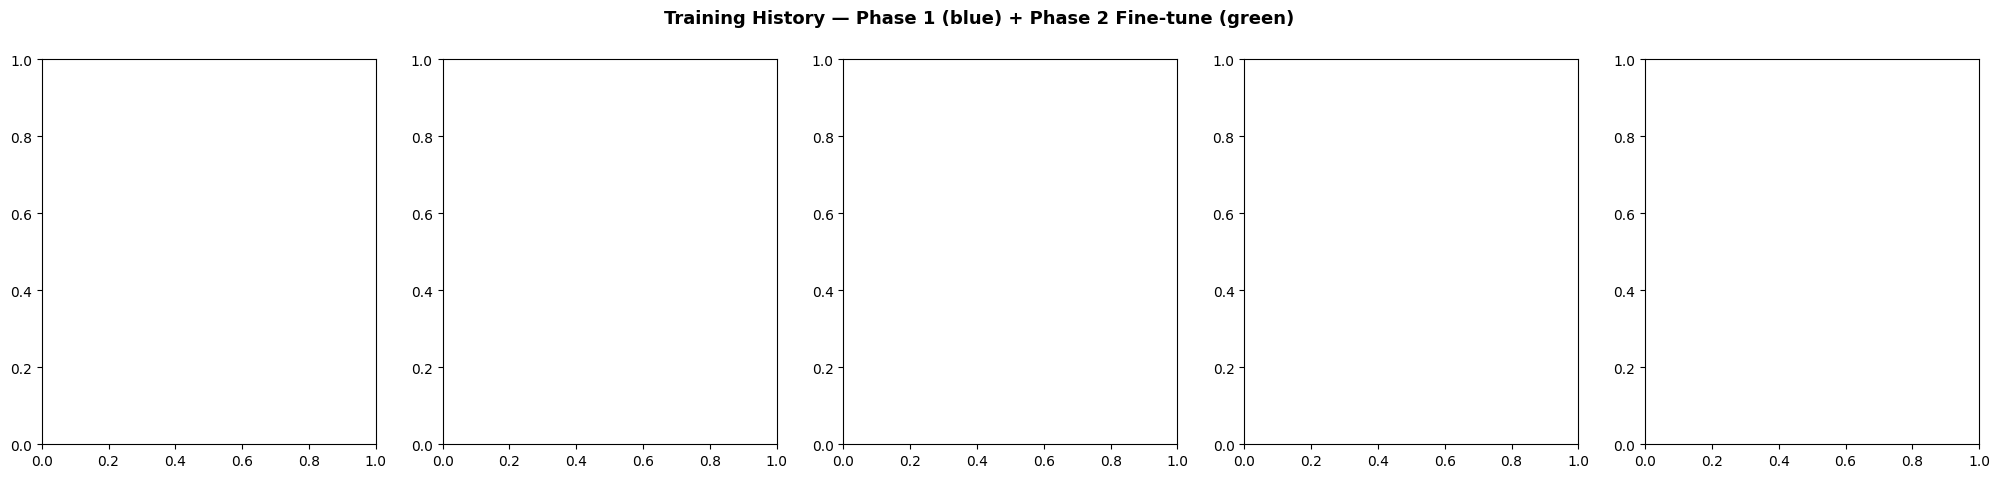

In [14]:
def safe_merge(h1, h2, key):
    return h1.history.get(key, []) + h2.history.get(key, [])

p1_end = len(history_p1.history['accuracy'])

metrics_pairs = [
    ('accuracy',  'val_accuracy',  'Accuracy'),
    ('loss',      'val_loss',      'Loss'),
    ('auc',       'val_auc',       'AUC'),
    ('precision', 'val_precision', 'Precision'),
    ('recall',    'val_recall',    'Recall'),
]

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Training History — Phase 1 (blue) + Phase 2 Fine-tune (green)',
             fontsize=13, fontweight='bold')

for ax, (tk, vk, title) in zip(axes, metrics_pairs):
    tv = safe_merge(history_p1, history_p2, tk)
    vv = safe_merge(history_p1, history_p2, vk)
    ep = range(1, len(tv)+1)

    ax.fill_between(range(1, p1_end+1), 0, 1, alpha=0.04,
                    color='blue', transform=ax.get_xaxis_transform())
    ax.fill_between(range(p1_end+1, len(tv)+1), 0, 1, alpha=0.06,
                    color='green', transform=ax.get_xaxis_transform())
    ax.plot(ep, tv, 'b-o', ms=3, lw=1.5, label='Train')
    ax.plot(ep, vv, 'r-o', ms=3, lw=1.5, label='Val')
    ax.axvline(p1_end+0.5, color='green', ls='--', lw=2, label='Fine-tune start')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'training_history.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Overfit diagnostic
final_tr = safe_merge(history_p1, history_p2, 'accuracy')[-1]
final_vl = safe_merge(history_p1, history_p2, 'val_accuracy')[-1]
gap      = final_tr - final_vl
print(f'Train acc: {final_tr:.4f}  |  Val acc: {final_vl:.4f}  |  Gap: {gap:.4f}')
if gap < 0.05:
    print('✅ Gap < 5% — well generalised')
elif gap < 0.12:
    print('🟡 Gap 5–12% — acceptable for 1439 images')
else:
    print('❌ Gap > 12% — still overfitting')

## Cell 15 — Predict on Test Set

In [15]:
print('Predicting on test set...')
pred_probs   = model.predict(X_test, batch_size=BATCH, verbose=1)
pd_probs     = pred_probs[:, 1]
actual_label = y_test.copy()
pred_default = np.argmax(pred_probs, axis=1)

print('\n=== Default Threshold (0.50) ===')
print(classification_report(actual_label, pred_default, target_names=labels))

# Quick check
ctrl_recall_default = recall_score(actual_label, pred_default, pos_label=0, zero_division=0)
print(f'CONTROL recall at 0.50 threshold: {ctrl_recall_default:.4f}  (was 0.00 before fix)')

Predicting on test set...
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step

=== Default Threshold (0.50) ===
              precision    recall  f1-score   support

     CONTROL       0.55      0.75      0.63        71
          PD       0.85      0.70      0.77       145

    accuracy                           0.72       216
   macro avg       0.70      0.72      0.70       216
weighted avg       0.75      0.72      0.73       216

CONTROL recall at 0.50 threshold: 0.7465  (was 0.00 before fix)


## Cell 16 — Optimal Threshold

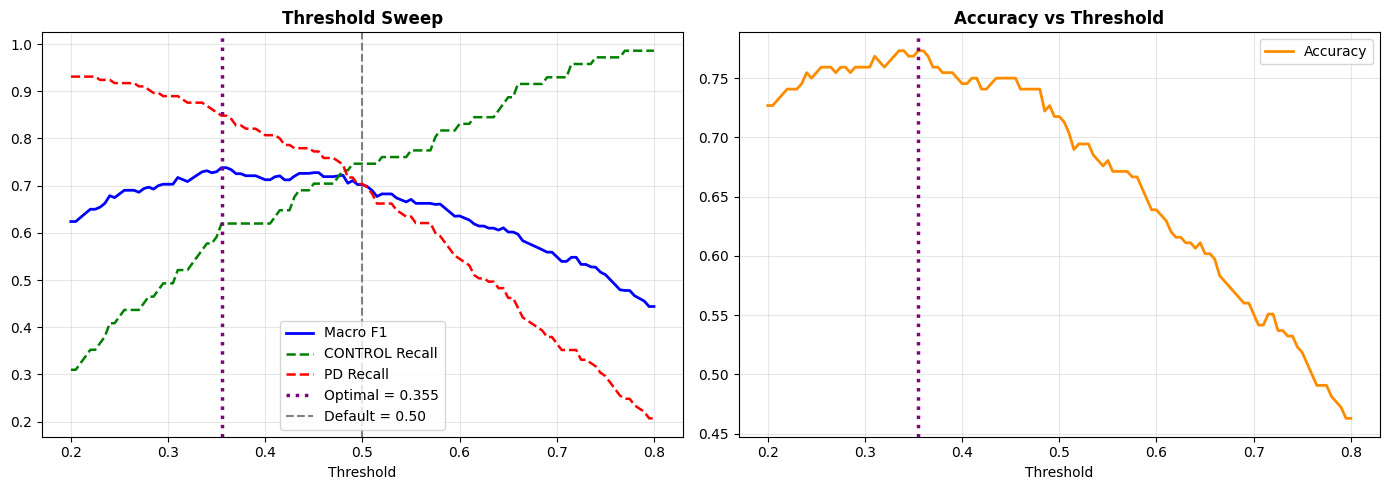

Optimal threshold : 0.355
Accuracy at opt   : 0.7731
Macro F1 at opt   : 0.7381

=== OPTIMAL THRESHOLD RESULTS ===
              precision    recall  f1-score   support

     CONTROL       0.67      0.62      0.64        71
          PD       0.82      0.85      0.83       145

    accuracy                           0.77       216
   macro avg       0.74      0.73      0.74       216
weighted avg       0.77      0.77      0.77       216



In [16]:
thresholds  = np.arange(0.20, 0.80, 0.005)
f1_macro    = []
ctrl_recall = []
pd_rec      = []
accs        = []

for t in thresholds:
    p = (pd_probs >= t).astype(int)
    f1_macro.append(f1_score(actual_label, p, average='macro', zero_division=0))
    ctrl_recall.append(recall_score(actual_label, p, pos_label=0, zero_division=0))
    pd_rec.append(recall_score(actual_label, p, pos_label=1, zero_division=0))
    accs.append(accuracy_score(actual_label, p))

best_idx    = np.argmax(f1_macro)
best_thresh = thresholds[best_idx]
pred_opt    = (pd_probs >= best_thresh).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresholds, f1_macro,    'b-',  lw=2,   label='Macro F1')
axes[0].plot(thresholds, ctrl_recall, 'g--', lw=1.8, label='CONTROL Recall')
axes[0].plot(thresholds, pd_rec,      'r--', lw=1.8, label='PD Recall')
axes[0].axvline(best_thresh, color='purple', ls=':', lw=2.5,
                label=f'Optimal = {best_thresh:.3f}')
axes[0].axvline(0.5, color='gray', ls='--', lw=1.5, label='Default = 0.50')
axes[0].set_title('Threshold Sweep', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Threshold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds, accs, 'darkorange', lw=2, label='Accuracy')
axes[1].axvline(best_thresh, color='purple', ls=':', lw=2.5)
axes[1].set_title('Accuracy vs Threshold', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Threshold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'threshold_optimisation.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'Optimal threshold : {best_thresh:.3f}')
print(f'Accuracy at opt   : {accs[best_idx]:.4f}')
print(f'Macro F1 at opt   : {f1_macro[best_idx]:.4f}')
print('\n=== OPTIMAL THRESHOLD RESULTS ===')
print(classification_report(actual_label, pred_opt, target_names=labels))

## Cell 17 — Full Metrics Table

In [17]:
def all_metrics(y_true, y_pred, y_prob, name):
    return {
        'Config'       : name,
        'Accuracy'     : accuracy_score(y_true, y_pred),
        'Prec (W)'     : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (W)'   : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 (W)'       : f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 (Macro)'   : f1_score(y_true, y_pred, average='macro', zero_division=0),
        'ROC-AUC'      : roc_auc_score(y_true, y_prob),
        'CTRL Recall'  : recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        'PD Recall'    : recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

df_m = pd.DataFrame([
    all_metrics(actual_label, pred_default, pd_probs, 'Threshold 0.50 (default)'),
    all_metrics(actual_label, pred_opt,     pd_probs, f'Threshold {best_thresh:.3f} (optimal)'),
]).set_index('Config')

print('\n' + '='*75)
print('  📊  FULL METRICS')
print('='*75)
print(df_m.to_string(float_format=lambda x: f'{x:.4f}'))
print('='*75)

prec_pc = precision_score(actual_label, pred_opt, average=None, zero_division=0)
rec_pc  = recall_score(actual_label,    pred_opt, average=None, zero_division=0)
f1_pc   = f1_score(actual_label,        pred_opt, average=None, zero_division=0)
acc_opt = accuracy_score(actual_label, pred_opt)
roc_auc_val = roc_auc_score(actual_label, pd_probs)

fpr, tpr, _         = roc_curve(actual_label, pd_probs)
p_curve, r_curve, _ = precision_recall_curve(actual_label, pd_probs)
ap_score            = average_precision_score(actual_label, pd_probs)

cnf_default = confusion_matrix(actual_label, pred_default)
cnf_opt     = confusion_matrix(actual_label, pred_opt)
cnf_norm    = cnf_opt.astype(float) / cnf_opt.sum(axis=1)[:, np.newaxis]

w_prec = precision_score(actual_label, pred_opt, average='weighted', zero_division=0)
w_rec  = recall_score(actual_label,    pred_opt, average='weighted', zero_division=0)
w_f1   = f1_score(actual_label,        pred_opt, average='weighted', zero_division=0)
m_f1   = f1_score(actual_label,        pred_opt, average='macro',    zero_division=0)


  📊  FULL METRICS
                           Accuracy  Prec (W)  Recall (W)  F1 (W)  F1 (Macro)  ROC-AUC  CTRL Recall  PD Recall
Config                                                                                                        
Threshold 0.50 (default)     0.7176    0.7521      0.7176  0.7254      0.7023   0.7949       0.7465     0.7034
Threshold 0.355 (optimal)    0.7731    0.7696      0.7731  0.7709      0.7381   0.7949       0.6197     0.8483


## Cell 18 — Confusion Matrices

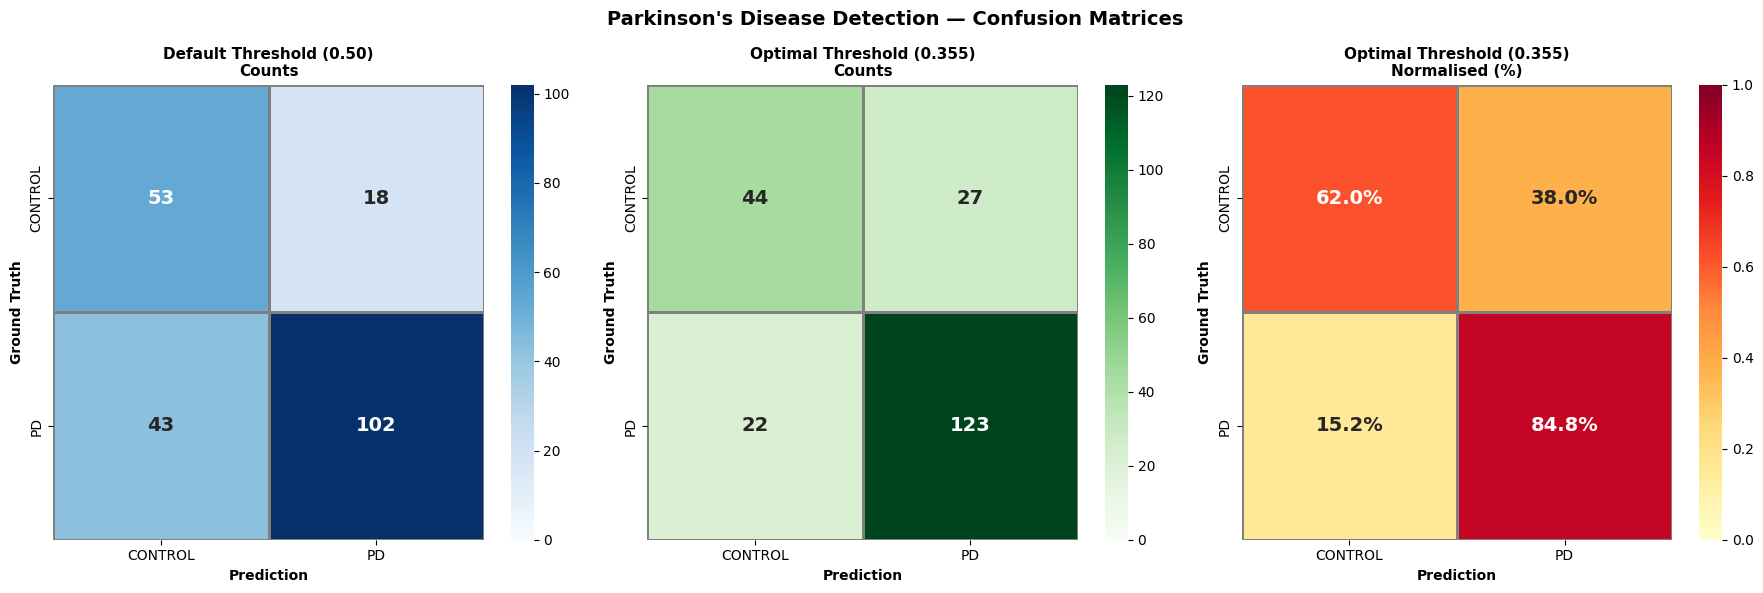

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Parkinson's Disease Detection — Confusion Matrices",
             fontsize=14, fontweight='bold')

for ax, cnf, cmap, title in zip(
    axes,
    [cnf_default, cnf_opt, cnf_norm],
    ['Blues', 'Greens', 'YlOrRd'],
    ['Default Threshold (0.50)\nCounts',
     f'Optimal Threshold ({best_thresh:.3f})\nCounts',
     f'Optimal Threshold ({best_thresh:.3f})\nNormalised (%)'],
):
    fmt  = '.1%' if 'Normalised' in title else 'd'
    vmax = 1     if 'Normalised' in title else None
    sns.heatmap(
        cnf, annot=True, fmt=fmt, cmap=cmap, ax=ax,
        xticklabels=labels, yticklabels=labels,
        linewidths=1, linecolor='gray',
        annot_kws={'size': 14, 'weight': 'bold'},
        vmin=0, vmax=vmax
    )
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Prediction', fontweight='bold')
    ax.set_ylabel('Ground Truth', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'confusion_matrix.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 19 — ROC & Precision-Recall Curves

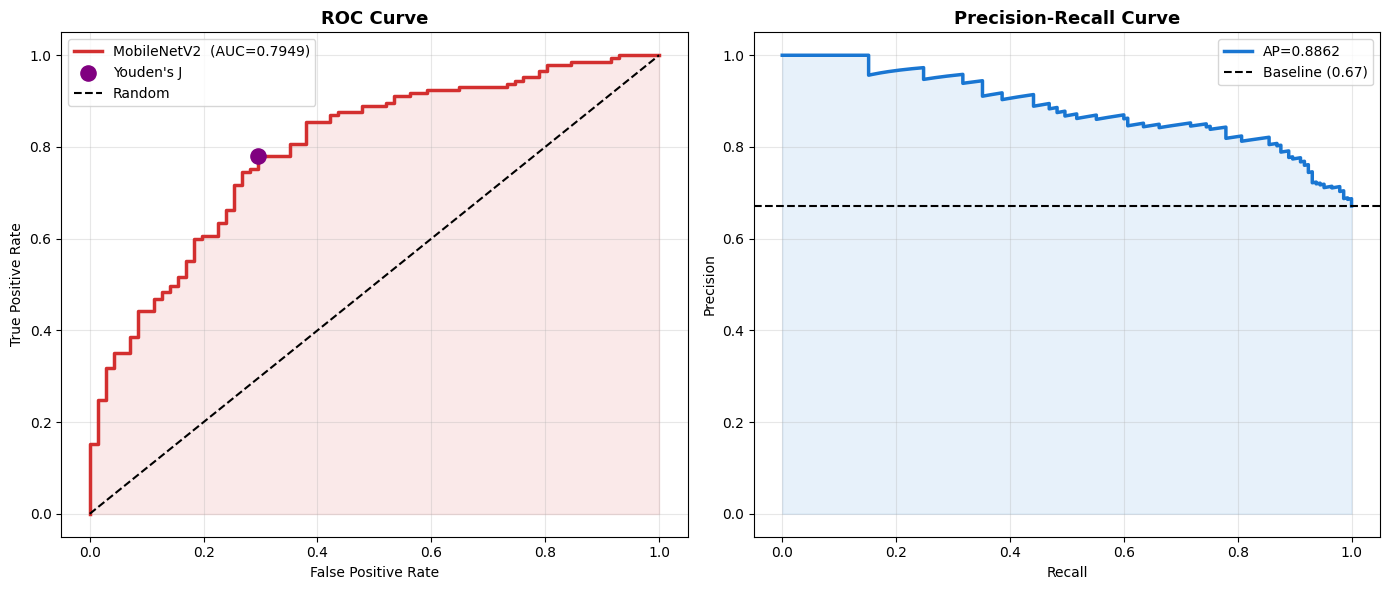

ROC-AUC       : 0.7949
Avg Precision : 0.8862


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

j_idx = np.argmax(tpr - fpr)
axes[0].plot(fpr, tpr, '#D32F2F', lw=2.5,
             label=f'MobileNetV2  (AUC={roc_auc_val:.4f})')
axes[0].scatter(fpr[j_idx], tpr[j_idx], s=120, color='purple',
                zorder=5, label="Youden's J")
axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.10, color='#D32F2F')
axes[0].set_title('ROC Curve', fontweight='bold', fontsize=13)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)

baseline = np.sum(y_test==1) / len(y_test)
axes[1].plot(r_curve, p_curve, '#1976D2', lw=2.5,
             label=f'AP={ap_score:.4f}')
axes[1].axhline(baseline, color='k', ls='--', lw=1.5,
                label=f'Baseline ({baseline:.2f})')
axes[1].fill_between(r_curve, p_curve, alpha=0.10, color='#1976D2')
axes[1].set_title('Precision-Recall Curve', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=10); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'roc_pr_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f'ROC-AUC       : {roc_auc_val:.4f}')
print(f'Avg Precision : {ap_score:.4f}')

## Cell 20 — Per-Class Metrics Bar Chart

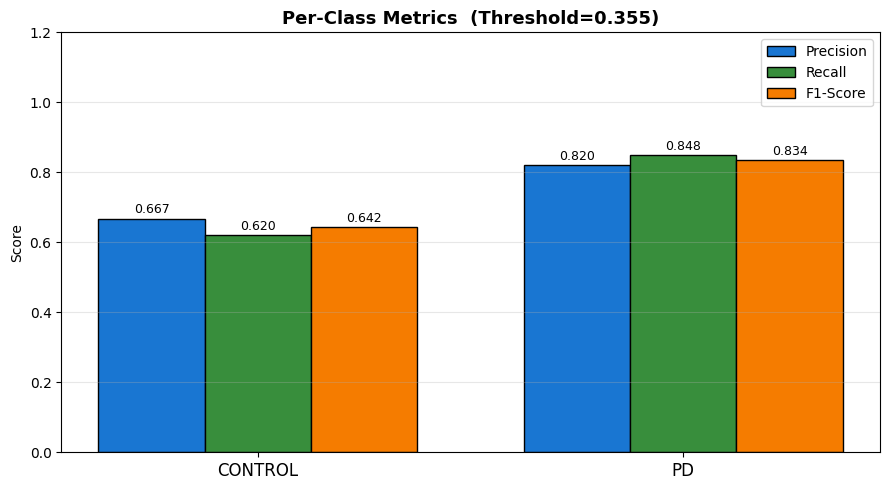

In [20]:
x = np.arange(NUM_CLASSES); w = 0.25
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x-w, prec_pc, w, label='Precision', color='#1976D2', edgecolor='black')
ax.bar(x,   rec_pc,  w, label='Recall',    color='#388E3C', edgecolor='black')
ax.bar(x+w, f1_pc,   w, label='F1-Score',  color='#F57C00', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.2); ax.set_ylabel('Score')
ax.set_title(f'Per-Class Metrics  (Threshold={best_thresh:.3f})',
             fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'per_class_metrics.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 21 — Probability Distributions

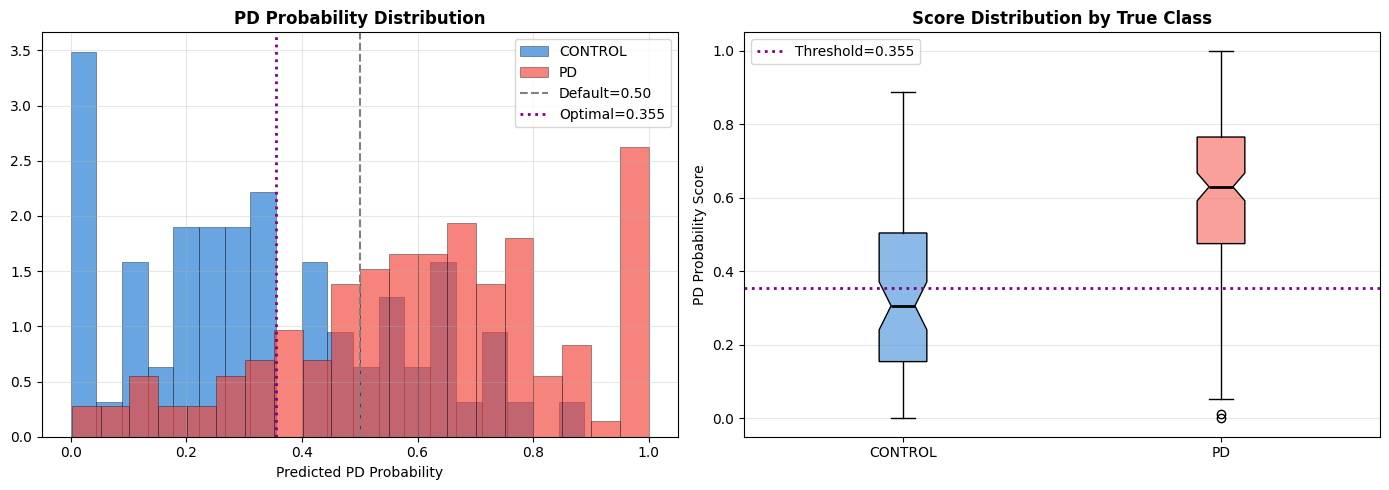

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ci, (cn, col) in enumerate(zip(labels, ['#1976D2','#F44336'])):
    mask = actual_label==ci
    axes[0].hist(pd_probs[mask], bins=20, alpha=0.65, color=col,
                 edgecolor='black', lw=0.4, label=cn, density=True)
axes[0].axvline(0.5,         color='gray',   ls='--', lw=1.5, label='Default=0.50')
axes[0].axvline(best_thresh, color='purple', ls=':',  lw=2,
                label=f'Optimal={best_thresh:.3f}')
axes[0].set_title('PD Probability Distribution', fontweight='bold')
axes[0].set_xlabel('Predicted PD Probability')
axes[0].legend(); axes[0].grid(alpha=0.3)

bp = axes[1].boxplot(
    [pd_probs[actual_label==0], pd_probs[actual_label==1]],
    labels=labels, patch_artist=True, notch=True,
    medianprops={'color':'black','lw':2}
)
bp['boxes'][0].set_facecolor('#1976D280')
bp['boxes'][1].set_facecolor('#F4433680')
axes[1].axhline(best_thresh, color='purple', ls=':', lw=2,
                label=f'Threshold={best_thresh:.3f}')
axes[1].set_title('Score Distribution by True Class', fontweight='bold')
axes[1].set_ylabel('PD Probability Score')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'probability_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 22 — Grad-CAM

Grad-CAM target (base model): Conv_1


KeyError: "Exception encountered when calling Functional.call().\n\n\x1b[1m1666467391248\x1b[0m\n\nArguments received by Functional.call():\n  • inputs=array([[[[-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         ...,\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745]],\n\n        [[-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         ...,\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745]],\n\n        [[-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         [-0.96862745, -0.96862745, -0.96862745],\n         ...,\n         [-0.96862745, -0.968627

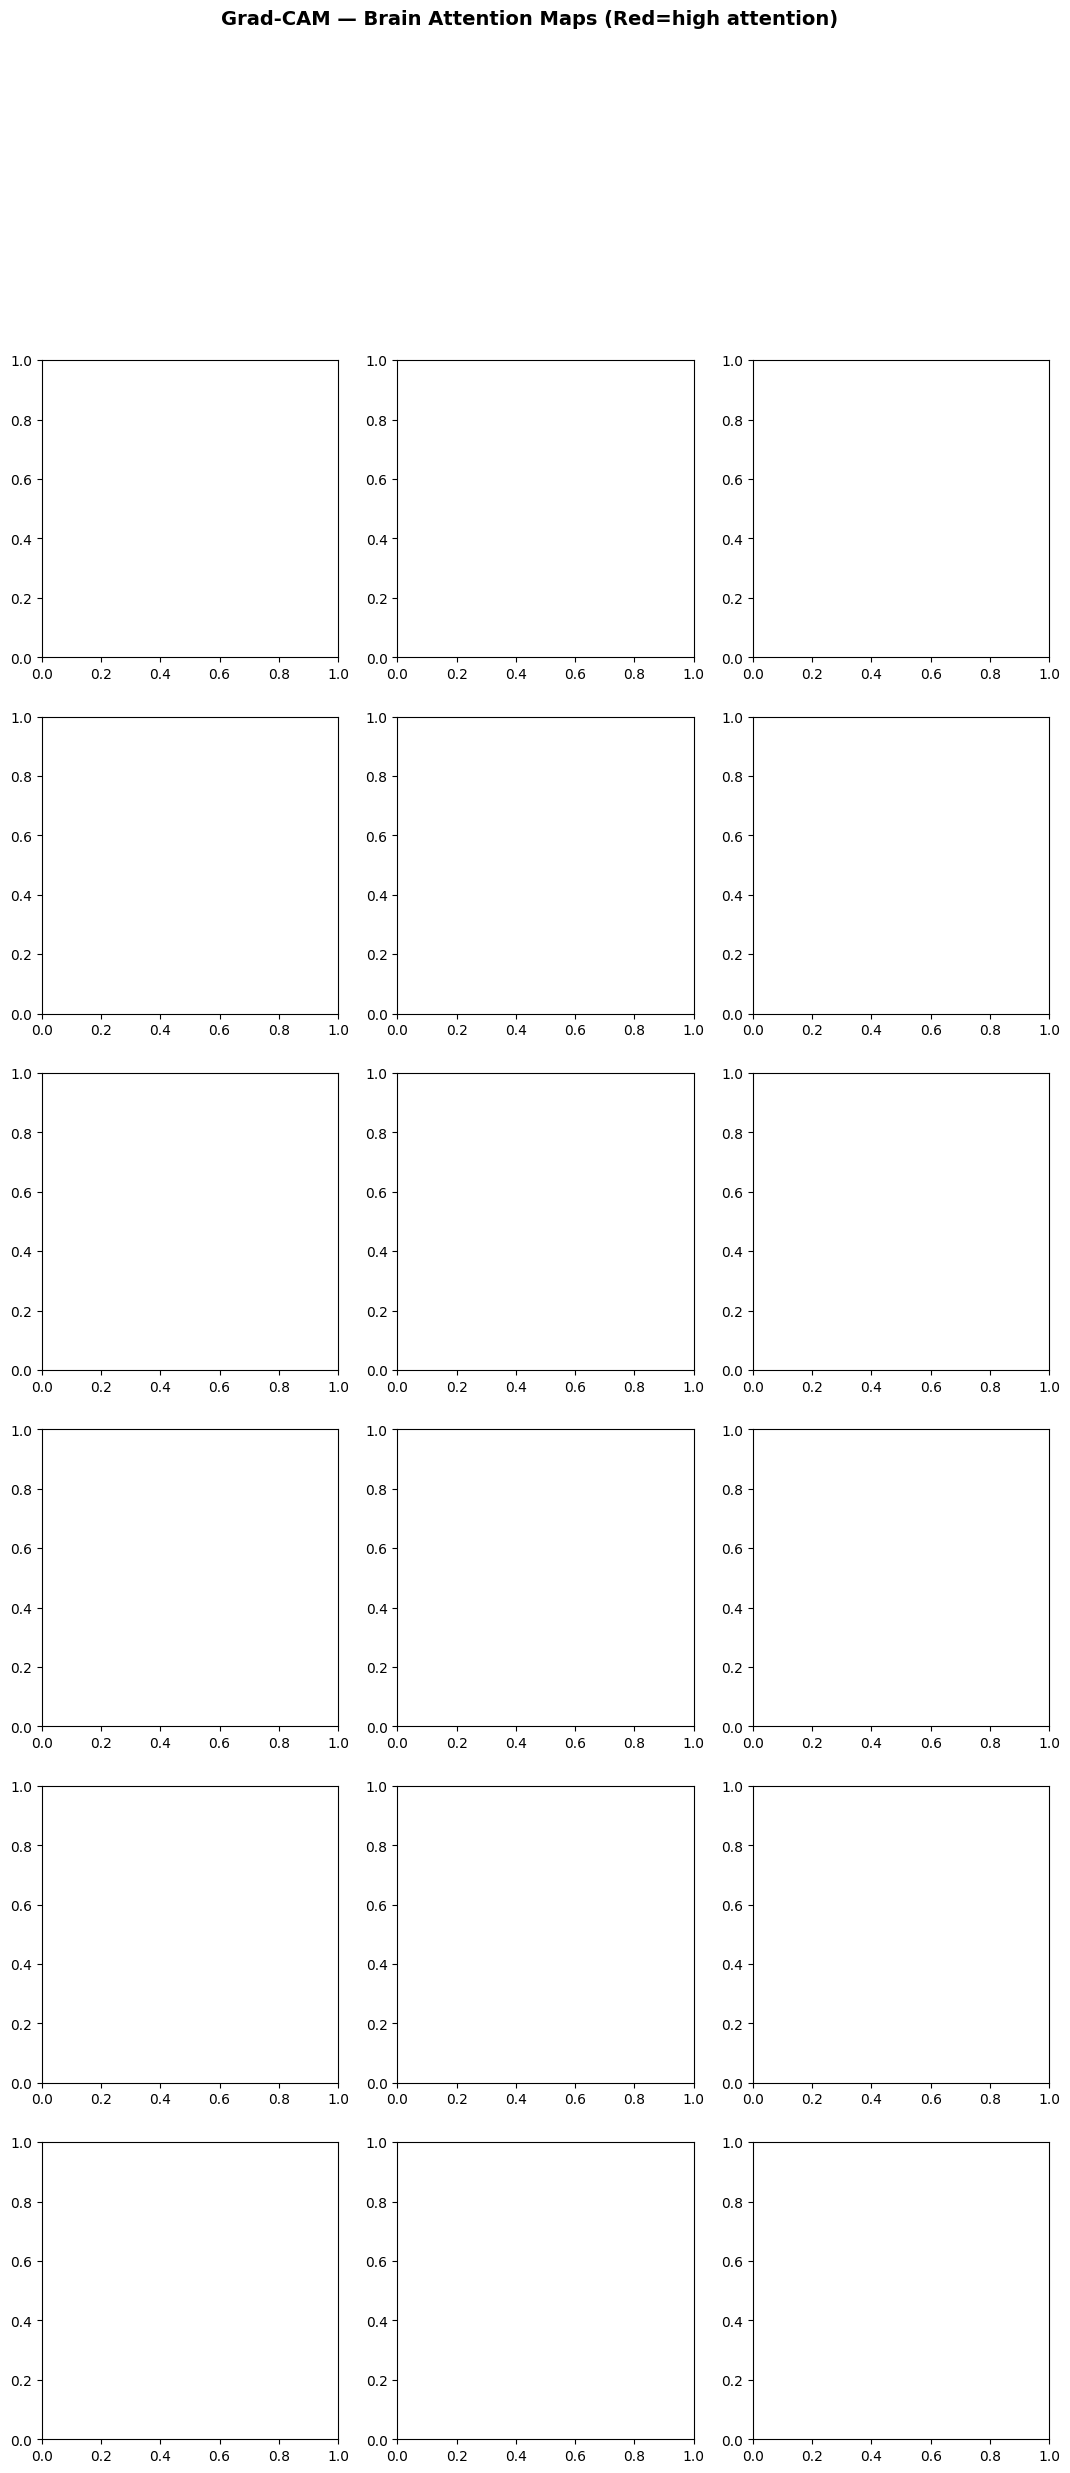

In [22]:
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv = layer.name; break
    if hasattr(layer, 'layers'):  # nested model (base)
        for sub in reversed(layer.layers):
            if isinstance(sub, layers.Conv2D):
                last_conv = sub.name; break
    if last_conv:
        break

# Build grad model on the base directly
last_conv_base = None
for layer in reversed(base_model.layers):
    if isinstance(layer, layers.Conv2D):
        last_conv_base = layer.name; break
print(f'Grad-CAM target (base model): {last_conv_base}')

grad_model = keras.Model(
    inputs  = model.inputs,
    outputs = [base_model.get_layer(last_conv_base).output, model.output]
)

def gradcam(img_arr):
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_arr, training=False)
        loss = preds[0][1]
    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0,1,2))
    hm      = tf.reduce_sum(tf.multiply(pooled, conv_out[0]), axis=-1)
    hm      = tf.maximum(hm, 0) / (tf.math.reduce_max(hm) + 1e-8)
    return hm.numpy(), float(preds[0][1].numpy())

def overlay(img_proc, hm, alpha=0.45):
    # img_proc is in [-1,1]; shift to [0,255] for display
    orig  = np.uint8(((img_proc + 1) / 2) * 255)
    h, w  = orig.shape[:2]
    hm_r  = cv2.resize(hm, (w, h))
    hm_c  = cv2.applyColorMap(np.uint8(255*hm_r), cv2.COLORMAP_INFERNO)
    hm_c  = cv2.cvtColor(hm_c, cv2.COLOR_BGR2RGB)
    return np.uint8(alpha*hm_c + (1-alpha)*orig)

N = 3
fig, axes = plt.subplots(NUM_CLASSES*N, 3,
                          figsize=(13, 4.5*NUM_CLASSES*N))
fig.suptitle('Grad-CAM — Brain Attention Maps (Red=high attention)',
             fontsize=14, fontweight='bold', y=1.01)

row = 0
for cls_i, cls_name in enumerate(labels):
    idxs = np.where(actual_label==cls_i)[0][:N]
    for idx in idxs:
        inp      = np.expand_dims(X_test[idx], 0).astype(np.float32)
        hm, prob = gradcam(inp)
        ov       = overlay(X_test[idx], hm)
        disp     = np.clip((X_test[idx]+1)/2, 0, 1)  # shift for display

        axes[row][0].imshow(disp)
        axes[row][0].set_title(f'MRI [True: {cls_name}]', fontsize=9, fontweight='bold')
        axes[row][0].axis('off')

        im = axes[row][1].imshow(hm, cmap='inferno')
        plt.colorbar(im, ax=axes[row][1], fraction=0.046)
        axes[row][1].set_title('Attention Heatmap', fontsize=9)
        axes[row][1].axis('off')

        pred_l  = 'PD' if prob >= best_thresh else 'CONTROL'
        correct = '✓' if pred_l==cls_name else '✗'
        col     = 'green' if pred_l==cls_name else 'red'
        axes[row][2].imshow(ov)
        axes[row][2].set_title(
            f'Overlay {correct}  Pred:{pred_l} ({prob:.1%})',
            fontsize=9, color=col, fontweight='bold'
        )
        axes[row][2].axis('off')
        row += 1

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'gradcam_heatmaps.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## Cell 23 — Misclassification Audit

Misclassified : 49 / 216
  FN (missed PD)      : 22
  FP (false alarm)    : 27


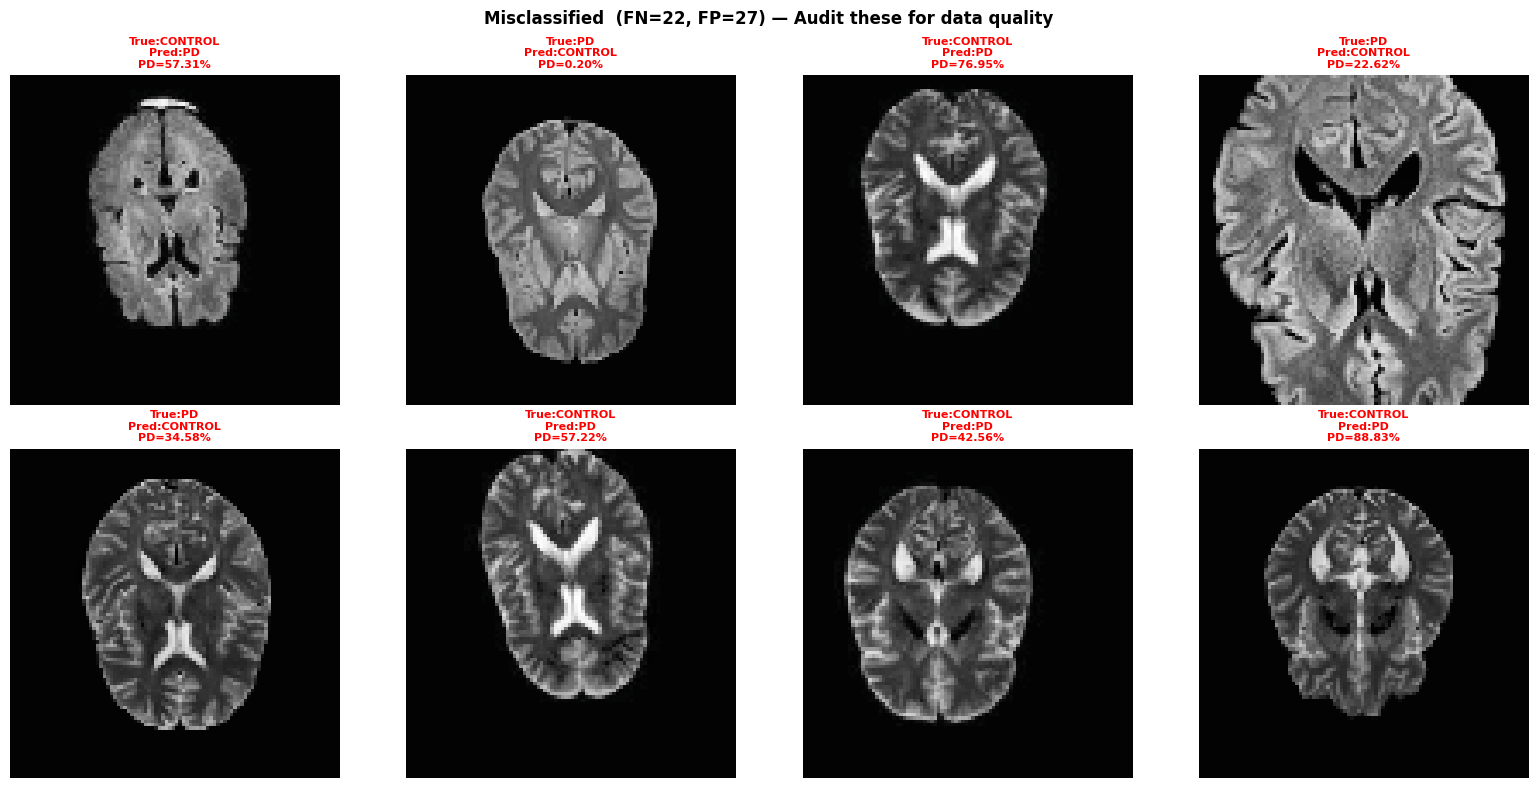

In [23]:
wrong_idxs = np.where(pred_opt != actual_label)[0]
fn = np.sum((pred_opt==0) & (actual_label==1))
fp = np.sum((pred_opt==1) & (actual_label==0))
print(f'Misclassified : {len(wrong_idxs)} / {len(actual_label)}')
print(f'  FN (missed PD)      : {fn}')
print(f'  FP (false alarm)    : {fp}')

if len(wrong_idxs) > 0:
    n_show = min(8, len(wrong_idxs))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes_f = axes.flatten()
    fig.suptitle(f'Misclassified  (FN={fn}, FP={fp}) — Audit these for data quality',
                 fontsize=12, fontweight='bold')
    for i, idx in enumerate(wrong_idxs[:n_show]):
        disp = np.clip((X_test[idx]+1)/2, 0, 1)
        axes_f[i].imshow(disp)
        axes_f[i].set_title(
            f'True:{labels[actual_label[idx]]}\nPred:{labels[pred_opt[idx]]}\nPD={pd_probs[idx]:.2%}',
            fontsize=8, color='red', fontweight='bold'
        )
        axes_f[i].axis('off')
    for j in range(n_show, 8):
        axes_f[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['output_dir'], 'misclassified.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

## Cell 24 — Complete Results Dashboard

NameError: name 'history_p2' is not defined

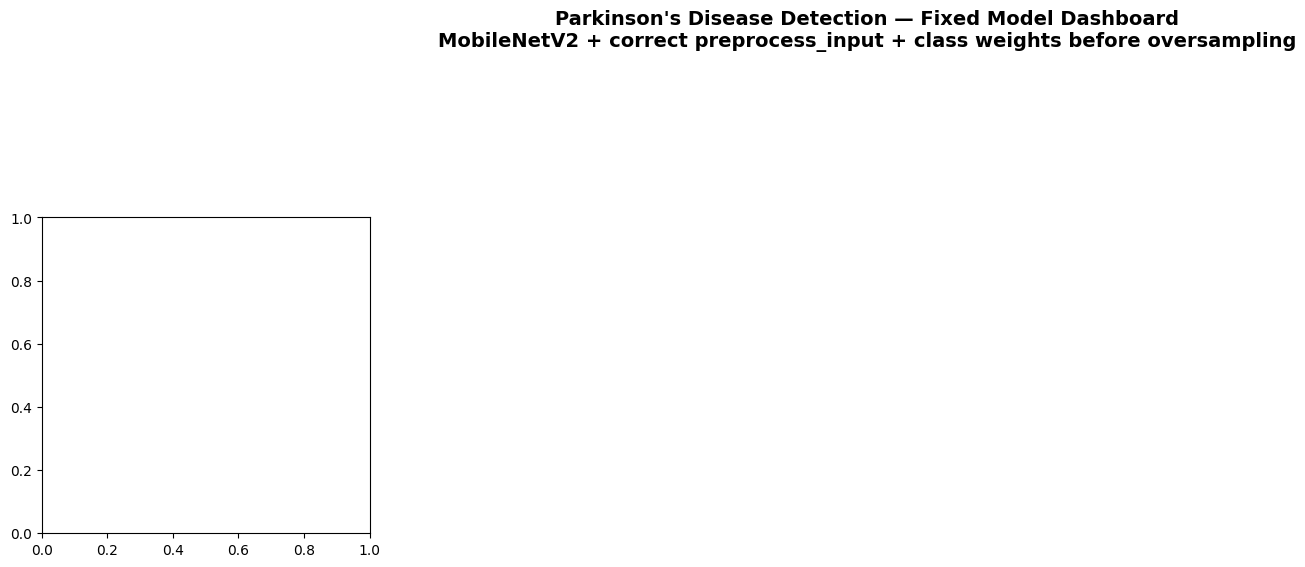

In [24]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(22, 16))
fig.suptitle(
    "Parkinson's Disease Detection — Fixed Model Dashboard\n"
    "MobileNetV2 + correct preprocess_input + class weights before oversampling",
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.4)

def safe_merge(h1, h2, k): return h1.history.get(k,[]) + h2.history.get(k,[])

# 1 Accuracy
ax1=fig.add_subplot(gs[0,0])
tv=safe_merge(history_p1,history_p2,'accuracy'); vv=safe_merge(history_p1,history_p2,'val_accuracy')
ax1.plot(range(1,len(tv)+1),tv,'b-o',ms=2,label='Train'); ax1.plot(range(1,len(vv)+1),vv,'r-o',ms=2,label='Val')
ax1.axvline(p1_end+0.5,color='green',ls='--',lw=1.5); ax1.set_title('Accuracy',fontweight='bold'); ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# 2 Loss
ax2=fig.add_subplot(gs[0,1])
tl=safe_merge(history_p1,history_p2,'loss'); vl=safe_merge(history_p1,history_p2,'val_loss')
ax2.plot(range(1,len(tl)+1),tl,'b-o',ms=2,label='Train'); ax2.plot(range(1,len(vl)+1),vl,'r-o',ms=2,label='Val')
ax2.axvline(p1_end+0.5,color='green',ls='--',lw=1.5); ax2.set_title('Loss',fontweight='bold'); ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# 3 AUC
ax3=fig.add_subplot(gs[0,2])
ta=safe_merge(history_p1,history_p2,'auc'); va=safe_merge(history_p1,history_p2,'val_auc')
ax3.plot(range(1,len(ta)+1),ta,'b-o',ms=2,label='Train'); ax3.plot(range(1,len(va)+1),va,'r-o',ms=2,label='Val')
ax3.axvline(p1_end+0.5,color='green',ls='--',lw=1.5); ax3.set_title('AUC History',fontweight='bold'); ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# 4 Threshold sweep
ax4=fig.add_subplot(gs[0,3])
ax4.plot(thresholds,f1_macro,'b-',lw=1.5,label='Macro F1')
ax4.plot(thresholds,ctrl_recall,'g--',lw=1.2,label='CTRL Recall')
ax4.plot(thresholds,pd_rec,'r--',lw=1.2,label='PD Recall')
ax4.axvline(best_thresh,color='purple',ls=':',lw=2); ax4.set_title('Threshold Sweep',fontweight='bold'); ax4.legend(fontsize=7); ax4.grid(alpha=0.3)

# 5 CM default
ax5=fig.add_subplot(gs[1,0])
sns.heatmap(cnf_default,annot=True,fmt='d',cmap='Blues',xticklabels=labels,yticklabels=labels,ax=ax5,linewidths=0.5,annot_kws={'size':13})
ax5.set_title('CM Default (0.50)',fontweight='bold'); ax5.set_xlabel('Pred'); ax5.set_ylabel('True')

# 6 CM optimal
ax6=fig.add_subplot(gs[1,1])
sns.heatmap(cnf_opt,annot=True,fmt='d',cmap='Greens',xticklabels=labels,yticklabels=labels,ax=ax6,linewidths=0.5,annot_kws={'size':13})
ax6.set_title(f'CM Optimal ({best_thresh:.3f})',fontweight='bold'); ax6.set_xlabel('Pred'); ax6.set_ylabel('True')

# 7 CM normalised
ax7=fig.add_subplot(gs[1,2])
sns.heatmap(cnf_norm,annot=True,fmt='.1%',cmap='YlOrRd',xticklabels=labels,yticklabels=labels,ax=ax7,linewidths=0.5,vmin=0,vmax=1)
ax7.set_title('CM Normalised',fontweight='bold'); ax7.set_xlabel('Pred'); ax7.set_ylabel('True')

# 8 Per-class metrics
ax8=fig.add_subplot(gs[1,3])
x_=np.arange(NUM_CLASSES); w_=0.25
ax8.bar(x_-w_,prec_pc,w_,color='#1976D2',edgecolor='k',label='Precision')
ax8.bar(x_,rec_pc,w_,color='#388E3C',edgecolor='k',label='Recall')
ax8.bar(x_+w_,f1_pc,w_,color='#F57C00',edgecolor='k',label='F1')
ax8.set_xticks(x_); ax8.set_xticklabels(labels); ax8.set_ylim(0,1.2)
ax8.set_title('Per-Class Metrics',fontweight='bold'); ax8.legend(fontsize=7); ax8.grid(axis='y',alpha=0.3)
for c in ax8.containers: ax8.bar_label(c,fmt='%.2f',fontsize=7,padding=1)

# 9 ROC
ax9=fig.add_subplot(gs[2,0])
ax9.plot(fpr,tpr,'#D32F2F',lw=2,label=f'AUC={roc_auc_val:.4f}')
ax9.plot([0,1],[0,1],'k--',lw=1); ax9.fill_between(fpr,tpr,alpha=0.08,color='#D32F2F')
ax9.set_title('ROC',fontweight='bold'); ax9.legend(fontsize=8); ax9.grid(alpha=0.3)
ax9.set_xlabel('FPR'); ax9.set_ylabel('TPR')

# 10 PR
ax10=fig.add_subplot(gs[2,1])
ax10.plot(r_curve,p_curve,'#1976D2',lw=2,label=f'AP={ap_score:.4f}')
ax10.fill_between(r_curve,p_curve,alpha=0.10,color='#1976D2')
ax10.set_title('Precision-Recall',fontweight='bold'); ax10.legend(fontsize=8); ax10.grid(alpha=0.3)
ax10.set_xlabel('Recall'); ax10.set_ylabel('Precision')

# 11 PD distribution
ax11=fig.add_subplot(gs[2,2])
for ci,(cn,col) in enumerate(zip(labels,['#1976D2','#F44336'])):
    mask=actual_label==ci
    ax11.hist(pd_probs[mask],bins=18,alpha=0.65,color=col,label=cn,density=True)
ax11.axvline(best_thresh,color='purple',ls=':',lw=2)
ax11.set_title('PD Score Distribution',fontweight='bold'); ax11.legend(fontsize=7); ax11.grid(alpha=0.3)

# 12 Summary
ax12=fig.add_subplot(gs[2,3])
ax12.axis('off')
summary = (
    f"FIXED MODEL RESULTS\n"
    f"{'─'*30}\n"
    f"Model      : MobileNetV2\n"
    f"Input range: [-1, 1] ✅\n"
    f"Preprocess : CLAHE + mobilenet_v2\n"
    f"CW order   : before oversample ✅\n"
    f"Label smooth: disabled ✅\n"
    f"BN frozen  : always ✅\n"
    f"Threshold  : {best_thresh:.3f}\n\n"
    f"METRICS\n"
    f"{'─'*30}\n"
    f"Accuracy   : {acc_opt:.4f}\n"
    f"Precision W: {w_prec:.4f}\n"
    f"Recall W   : {w_rec:.4f}\n"
    f"F1 Weighted: {w_f1:.4f}\n"
    f"F1 Macro   : {m_f1:.4f}\n"
    f"ROC-AUC    : {roc_auc_val:.4f}\n\n"
    f"PER-CLASS\n"
    f"{'─'*30}\n"
    + '\n'.join([f'  {lbl:<12}: F1={f1_pc[i]:.4f}  Rec={rec_pc[i]:.4f}' for i,lbl in enumerate(labels)])
)
ax12.text(0.03,0.97,summary,transform=ax12.transAxes,fontsize=9,va='top',
          fontfamily='monospace',bbox=dict(boxstyle='round',facecolor='#E8F5E9',alpha=0.95))

plt.savefig(os.path.join(CONFIG['output_dir'],'results_dashboard.png'),dpi=150,bbox_inches='tight')
plt.show()
print('Saved: results_dashboard.png')

## Cell 25 — Save Summary & Final Report

In [27]:
summary_dict = {
    'model': 'MobileNetV2', 'image_size': IMG_SIZE,
    'optimal_threshold': float(best_thresh),
    'fixes_applied': [
        'mobilenet_v2.preprocess_input → [-1,1]',
        'class weights computed BEFORE oversampling',
        'label smoothing removed',
        'BatchNorm always frozen during fine-tune',
        'no rescale in ImageDataGenerator'
    ],
    'metrics': {
        'accuracy': float(acc_opt), 'f1_weighted': float(w_f1),
        'f1_macro': float(m_f1),    'roc_auc': float(roc_auc_val),
        'control_recall': float(rec_pc[0]), 'pd_recall': float(rec_pc[1]),
        'control_f1': float(f1_pc[0]),      'pd_f1': float(f1_pc[1]),
    },
    'training_time_min': round(p1_time/60, 1),
}
with open(os.path.join(CONFIG['output_dir'],'experiment_summary.json'),'w') as f:
    json.dump(summary_dict, f, indent=4)

print('='*60)
print('  🏁  FIXED MODEL COMPLETE')
print('='*60)
print(f'  Accuracy       : {acc_opt:.4f}')
print(f'  F1 Macro       : {m_f1:.4f}')
print(f'  ROC-AUC        : {roc_auc_val:.4f}')
print(f'  CONTROL Recall : {rec_pc[0]:.4f}  (was 0.00 before fix)')
print(f'  PD Recall      : {rec_pc[1]:.4f}')
print(f'  Training time  : {p1_time/60:.1f} min')
print('='*60)

  🏁  FIXED MODEL COMPLETE
  Accuracy       : 0.7731
  F1 Macro       : 0.7381
  ROC-AUC        : 0.7949
  CONTROL Recall : 0.6197  (was 0.00 before fix)
  PD Recall      : 0.8483
  Training time  : 6.3 min


## Cell 26 — Prediction Widget

In [26]:
def imagePrediction(upload_widget):
    for name, fileinfo in upload_widget.value.items():
        image = Image.open(io.BytesIO(fileinfo['content']))

    img_bgr  = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
    img_resz = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))

    # ✅ Use the same correct preprocessing as training
    img_proc = preprocess_mri_for_mobilenet(img_resz)
    inp      = np.expand_dims(img_proc, 0).astype(np.float32)

    probs    = model.predict(inp, verbose=0)
    pd_prob  = float(probs[0][1])
    pred_idx = 1 if pd_prob >= best_thresh else 0
    pred_lbl = labels[pred_idx]
    conf     = pd_prob if pred_idx==1 else (1-pd_prob)

    try:
        hm, _ = gradcam(inp); ov = overlay(img_proc, hm); has_gc = True
    except:
        has_gc = False

    ncols = 3 if has_gc else 1
    fig, axes = plt.subplots(1, ncols, figsize=(5*ncols, 5))
    if ncols == 1: axes = [axes]
    color = 'red' if pred_lbl=='PD' else 'green'
    axes[0].imshow(np.clip((img_proc+1)/2, 0, 1))
    axes[0].set_title(f'Prediction: {pred_lbl}\nConfidence: {conf:.1%}',
                      color=color, fontweight='bold', fontsize=13)
    axes[0].axis('off')
    if has_gc:
        axes[1].imshow(hm, cmap='inferno')
        axes[1].set_title('Brain Attention Map', fontweight='bold'); axes[1].axis('off')
        axes[2].imshow(ov)
        axes[2].set_title('Grad-CAM Overlay', fontweight='bold'); axes[2].axis('off')
    plt.tight_layout(); plt.show()
    print(f'🧠 Prediction : {pred_lbl}')
    print(f'   PD prob    : {probs[0][1]:.4f}')
    print(f'   CTRL prob  : {probs[0][0]:.4f}')
    print(f'   Threshold  : {best_thresh:.3f}')

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

In [29]:
button = widgets.Button(description='🔍 Predict', button_style='danger',
                        layout=widgets.Layout(width='160px', height='42px'))
out = widgets.Output()

def on_click(_):
    with out:
        clear_output()
        if not uploader.value:
            print('⚠️  Upload an MRI first.'); return
        try:
            imagePrediction(uploader)
        except Exception as e:
            print(f'❌ Error: {e}')

button.on_click(on_click)
widgets.VBox([button, out])